# Channel theory of scale calibration (pixel-space ELS and LS)

Load scale calibration files for pixel-space ELS and LS. At a given timestep we plot vs kernel size \(k\):
- Average entropy of the ELS and LS posteriors
- Center-pixel variance and Binder cumulant
- Total patch variance and total patch Binder cumulant

**Theory:** The fitted scale is assumed to minimize cost **β⟨d(x,x')⟩ − S** (higher entropy S is better). We infer β from the calibrated \(k^*\) and plot β for different rate-distortion choices.

In [3]:
import os
import sys
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

os.chdir('../')

# Project root
ROOT = Path(os.path.abspath("")).resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

In [4]:
from src.utils.data import get_dataset
from src.utils.idealscore import LocalEquivScoreModule, LocalScoreModule
from src.utils.noise_schedules import cosine_noise_schedule
from src.utils.channel_theory import (
    load_scale_calibration,
    collect_stats_vs_k,
    infer_beta_at_k_star,
    infer_betas_for_rate_distortion,
    cost_at_beta,
    t_to_snr,
)

In [14]:
# Config: pixel-space scale calibration (not latent)
dataset_name = "mnist"
kernelsizes = (3, 5, 7, 9, 11)
scale_file_ls = "scales_MNIST_ResNet_zeros.pt"   # e.g. "scales_MNIST_ResNet_zeros_LS_median.pt"
scale_file_els = "scales_MNIST_ResNet_zeros.pt"   # e.g. "scales_MNIST_ResNet_zeros_ELS_median.pt"
tld = "./checkpoints/"
nsteps = 20
nsamples = 4
timestep_idx = nsteps // 2
max_samples = 500
score_batch_size = 32
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [15]:
dataset, metadata = get_dataset(dataset_name, root=str(ROOT / "data"))
in_channels = metadata["num_channels"]
image_size = metadata["image_size"]

median_ls = load_scale_calibration(scale_file_ls, tld)
median_els = load_scale_calibration(scale_file_els, tld)

# Build LS and ELS modules for each k
ls_modules = []
for k in kernelsizes:
    mod = LocalScoreModule(
        dataset,
        kernel_size=k,
        image_size=image_size,
        batch_size=min(score_batch_size, len(dataset)),
        schedule=cosine_noise_schedule,
        max_samples=max_samples,
    )
    mod.to(device).eval()
    ls_modules.append((k, mod))

els_modules = []
for k in kernelsizes:
    mod = LocalEquivScoreModule(
        dataset,
        kernel_size=k,
        batch_size=score_batch_size,
        image_size=image_size,
        channels=in_channels,
        schedule=cosine_noise_schedule,
        max_samples=max_samples,
    )
    mod.to(device).eval()
    els_modules.append((k, mod))

In [16]:
t = (timestep_idx + 1) * torch.ones(1, device=device) / nsteps
torch.manual_seed(42)
x_batch = torch.randn(nsamples, in_channels, image_size, image_size, device=device)

stats_ls = collect_stats_vs_k(ls_modules, t, x_batch, device, label=None)
stats_els = collect_stats_vs_k(els_modules, t, x_batch, device, label=None)
k_vals = stats_ls["k_vals"]

RuntimeError: CUDA error: CUDA-capable device(s) is/are busy or unavailable
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


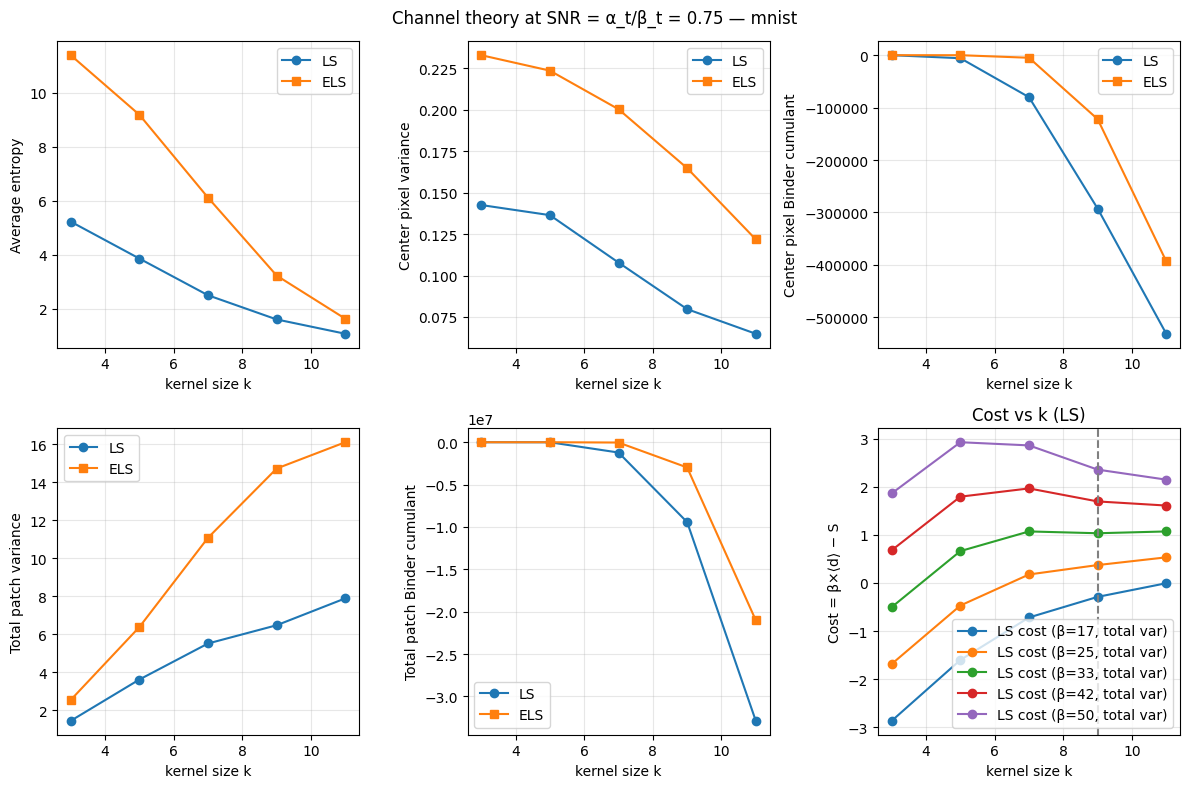

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
snr_current = float(t_to_snr(t.cpu(), cosine_noise_schedule))
fig.suptitle(f"Channel theory at SNR = α_t/β_t = {snr_current:.3g} — {dataset_name}")

axes[0, 0].plot(k_vals, stats_ls["avg_entropy"], "o-", label="LS")
axes[0, 0].plot(k_vals, stats_els["avg_entropy"], "s-", label="ELS")
axes[0, 0].set_xlabel("kernel size k"); axes[0, 0].set_ylabel("Average entropy"); axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(k_vals, stats_ls["center_variance"], "o-", label="LS")
axes[0, 1].plot(k_vals, stats_els["center_variance"], "s-", label="ELS")
axes[0, 1].set_xlabel("kernel size k"); axes[0, 1].set_ylabel("Center pixel variance"); axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].plot(k_vals, stats_ls["center_binder"], "o-", label="LS")
axes[0, 2].plot(k_vals, stats_els["center_binder"], "s-", label="ELS")
axes[0, 2].set_xlabel("kernel size k"); axes[0, 2].set_ylabel("Center pixel Binder cumulant"); axes[0, 2].legend(); axes[0, 2].grid(True, alpha=0.3)

axes[1, 0].plot(k_vals, stats_ls["total_variance"], "o-", label="LS")
axes[1, 0].plot(k_vals, stats_els["total_variance"], "s-", label="ELS")
axes[1, 0].set_xlabel("kernel size k"); axes[1, 0].set_ylabel("Total patch variance"); axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(k_vals, stats_ls["total_binder"], "o-", label="LS")
axes[1, 1].plot(k_vals, stats_els["total_binder"], "s-", label="ELS")
axes[1, 1].set_xlabel("kernel size k"); axes[1, 1].set_ylabel("Total patch Binder cumulant"); axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)

# Cost = β×⟨d⟩ − S: infer fitted β for this timestep, then plot cost for betas around it
betas_dict = infer_betas_for_rate_distortion(stats_ls, stats_els, median_ls, median_els, timestep_idx)
beta_fit = betas_dict.get(("LS", "center_variance"), np.nan)
if np.isfinite(beta_fit) and beta_fit > 0:
    betas_to_plot = beta_fit * np.array([0.5, 0.75, 1.0, 1.25, 1.5])
else:
    betas_to_plot = np.linspace(0, 2, 5)  # fallback when no scale calibration
for beta in betas_to_plot:
    cost = cost_at_beta(stats_ls["avg_entropy"], stats_ls["center_variance"], beta)
    axes[1, 2].plot(k_vals, cost, "o-", label=f"LS cost (β={beta:.2g}, total var)")
axes[1, 2].set_xlabel("kernel size k"); axes[1, 2].set_ylabel("Cost = β×⟨d⟩ − S"); axes[1, 2].legend(); axes[1, 2].grid(True, alpha=0.3)
axes[1, 2].set_title("Cost vs k (LS)")
if median_ls is not None and timestep_idx < median_ls.numel():
    axes[1, 2].axvline(median_ls[timestep_idx].item(), color="gray", linestyle="--", label="calibrated k (LS)")
plt.tight_layout()
plt.show()

#### Infer beta from calibrated k (cost minimizer: d(cost)/dk = 0 at k*)
betas = infer_betas_for_rate_distortion(stats_ls, stats_els, median_ls, median_els, timestep_idx)
if betas:
    fig2, ax = plt.subplots(1, 1, figsize=(8, 4))
    for (score_name, reg_name), beta in betas.items():
        if not np.isnan(beta):
            ax.bar(f"{score_name} — {reg_name}", beta, width=0.6)
    ax.set_ylabel("Inferred β (cost = β×⟨d⟩ − S)")
    ax.set_title("β for rate-distortion choices at this timestep")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No scale calibration loaded; set scale_file_ls / scale_file_els to see inferred β.")

In [7]:
betas_dict 

{('LS', 'center_variance'): 33.21649333482864,
 ('LS', 'center_binder'): 3.158189367814249e-06,
 ('LS', 'total_variance'): -0.600307140329959,
 ('LS', 'total_binder'): 4.503248460591686e-08,
 ('ELS', 'center_variance'): 57.12657615053436,
 ('ELS', 'center_binder'): 1.1545936591580457e-05,
 ('ELS', 'total_variance'): -0.8918180086065078,
 ('ELS', 'total_binder'): 2.1381997868577274e-07}

## Center variance only (rate-distortion)

Below we focus only on **center pixel variance** as the rate-distortion function: plot entropy and center variance vs \(k\) for LS and ELS at the current timestep, and infer \(\beta\) for center variance only (LS and ELS).

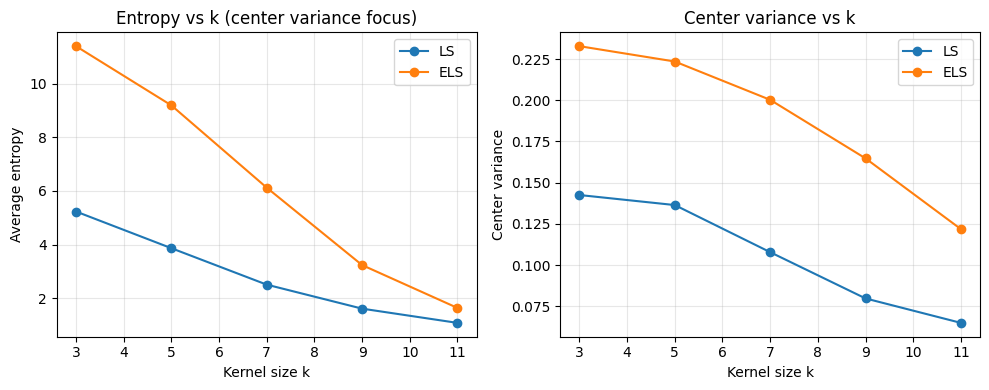

β (center variance only) at this timestep: LS = 33.21649333482864, ELS = 57.12657615053436


In [8]:
# Center variance only: entropy and center_variance vs k at current t
fig_cv, axes_cv = plt.subplots(1, 2, figsize=(10, 4))
axes_cv[0].plot(k_vals, stats_ls["avg_entropy"], "o-", label="LS")
axes_cv[0].plot(k_vals, stats_els["avg_entropy"], "o-", label="ELS")
axes_cv[0].set_xlabel("Kernel size k")
axes_cv[0].set_ylabel("Average entropy")
axes_cv[0].set_title("Entropy vs k (center variance focus)")
axes_cv[0].legend()
axes_cv[0].grid(True, alpha=0.3)

axes_cv[1].plot(k_vals, stats_ls["center_variance"], "o-", label="LS")
axes_cv[1].plot(k_vals, stats_els["center_variance"], "o-", label="ELS")
axes_cv[1].set_xlabel("Kernel size k")
axes_cv[1].set_ylabel("Center variance")
axes_cv[1].set_title("Center variance vs k")
axes_cv[1].legend()
axes_cv[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Infer β for center_variance only (LS and ELS)
beta_ls_cv = np.nan
beta_els_cv = np.nan
if median_ls is not None and timestep_idx < median_ls.numel():
    k_star = int(median_ls[timestep_idx].item())
    beta_ls_cv = infer_beta_at_k_star(stats_ls["avg_entropy"], stats_ls["center_variance"], list(k_vals), k_star)
if median_els is not None and timestep_idx < median_els.numel():
    k_star = int(median_els[timestep_idx].item())
    beta_els_cv = infer_beta_at_k_star(stats_els["avg_entropy"], stats_els["center_variance"], list(k_vals), k_star)
print(f"β (center variance only) at this timestep: LS = {beta_ls_cv}, ELS = {beta_els_cv}")

## Optional: β vs timestep (multiple steps)

To plot β as a function of timestep for each rate-distortion choice, we need to compute stats at several timesteps (expensive). The script `scripts/channel_theory_scale_calibration.py` does this and saves `channel_theory_beta_vs_step_*.png`. Below we sample a few steps for illustration.

In [ ]:
# Set to True to compute β at multiple timesteps (slow)
run_multi_step_beta = True
if run_multi_step_beta and (median_ls is not None or median_els is not None):
    step_indices = list(np.linspace(0, nsteps - 1, min(8, nsteps), dtype=int))
    step_indices = sorted(set(step_indices))
    betas_by_step = {}  # (score_name, reg_name) -> [(step_idx, beta), ...]
    for step_idx in step_indices:
        t_cur = (step_idx + 1) * torch.ones(1, device=device) / nsteps
        x_cur = torch.randn(nsamples, in_channels, image_size, image_size, device=device)
        st_ls = collect_stats_vs_k(ls_modules, t_cur, x_cur, device, None)
        st_els = collect_stats_vs_k(els_modules, t_cur, x_cur, device, None)
        b = infer_betas_for_rate_distortion(st_ls, st_els, median_ls, median_els, step_idx)
        print(b)
        for key, val in b.items():
            if key not in betas_by_step:
                betas_by_step[key] = []
            betas_by_step[key].append((step_idx, val))
    fig3, ax3 = plt.subplots(1, 1, figsize=(8, 5))
    for (score_name, reg_name), points in betas_by_step.items():
        points = sorted(points, key=lambda p: p[0])
        snr_vals = [float(t_to_snr((p[0] + 1) / nsteps, cosine_noise_schedule)) for p in points if not np.isnan(p[1])]
        vals = [p[1] for p in points if not np.isnan(p[1])]
        if snr_vals and vals:
            ax3.plot(snr_vals, vals, "o-", label=f"{score_name} — {reg_name}")
    ax3.set_xlabel("Signal-to-noise ratio α_t / β_t")
    ax3.set_ylabel("Inferred β")
    ax3.set_title("β vs SNR (from calibrated scale)")
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
elif not run_multi_step_beta:
    print("Skipping multi-step β (set run_multi_step_beta = True and load scale files to run).")

## β vs SNR from Slurm job (center variance only)

Run a Slurm job to collect statistics at **every** timestep and infer β (center variance only) at each SNR. The job script is `scripts/slurm_channel_theory_beta_vs_snr.sh`; it runs `scripts/channel_theory_beta_vs_snr_center_variance.py`. After the job completes, load the saved `.pt` file below to plot β vs SNR for LS and ELS (center variance only).

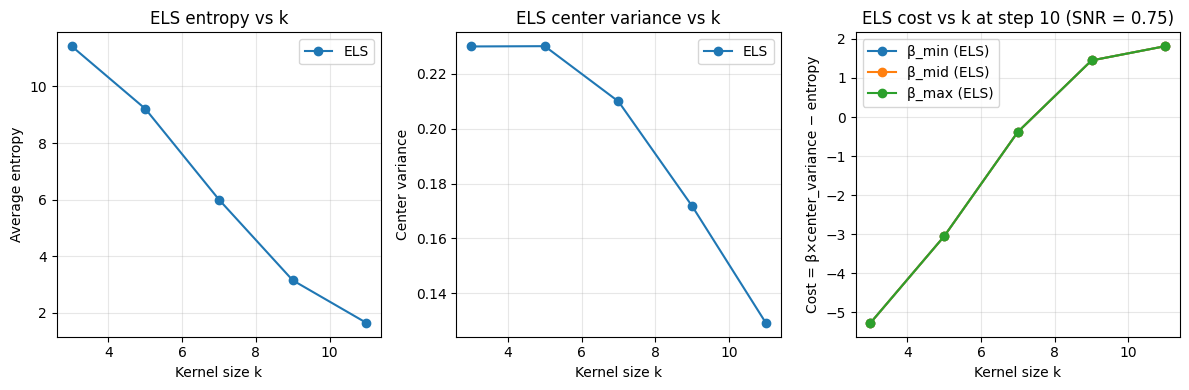

In [9]:
# Figuring out ELS problem in slurm output
# 1) Recompute ELS stats vs k at this timestep
# 2) Plot entropy and center_variance vs k
# 3) Use Slurm β_els range (min/mid/max) to plot the ELS cost landscape at this timestep

# Recompute local ELS stats vs k at the notebook's timestep
t_cur = (timestep_idx + 1) * torch.ones(1, device=device) / nsteps
torch.manual_seed(42 + int(timestep_idx))
x_cur = torch.randn(nsamples, in_channels, image_size, image_size, device=device)
stats_els = collect_stats_vs_k(els_modules, t_cur, x_cur, device, label=None)
k_vals = np.asarray(stats_els["k_vals"], dtype=np.float64)

fig_cv, axes_cv = plt.subplots(1, 3, figsize=(12, 4))

# Average entropy vs k (ELS)
axes_cv[0].plot(k_vals, stats_els["avg_entropy"], "o-", label="ELS")
axes_cv[0].set_xlabel("Kernel size k")
axes_cv[0].set_ylabel("Average entropy")
axes_cv[0].set_title("ELS entropy vs k")
axes_cv[0].legend()
axes_cv[0].grid(True, alpha=0.3)

# Center-pixel variance vs k (ELS)
axes_cv[1].plot(k_vals, stats_els["center_variance"], "o-", label="ELS")
axes_cv[1].set_xlabel("Kernel size k")
axes_cv[1].set_ylabel("Center variance")
axes_cv[1].set_title("ELS center variance vs k")
axes_cv[1].legend()
axes_cv[1].grid(True, alpha=0.3)

# Load Slurm β_els and its error range
slurm_out = ROOT / "results" / "channel_theory" / f"beta_vs_snr_center_variance_{dataset_name}.pt"
if slurm_out.exists():
    data = torch.load(slurm_out, map_location="cpu", weights_only=False)
    snr_arr = np.asarray(data["snr"], dtype=np.float64)
    def to_arr(key, default_nan=None):
        raw = data.get(key)
        if raw is None:
            return np.full(len(snr_arr), np.nan if default_nan is None else default_nan)
        return np.array([x if x is not None else np.nan for x in raw], dtype=np.float64)
    beta_els_arr = to_arr("beta_els")
    err_lo_els = to_arr("beta_els_err_lo", default_nan=0.0)
    err_hi_els = to_arr("beta_els_err_hi", default_nan=0.0)
    err_lo_els = np.where(np.isfinite(err_lo_els) & (err_lo_els > 0), err_lo_els, 0.0)
    err_hi_els = np.where(np.isfinite(err_hi_els) & (err_hi_els > 0), err_hi_els, 0.0)

    step_idx_to_inspect = int(timestep_idx)
    if 0 <= step_idx_to_inspect < len(snr_arr) and np.isfinite(
        beta_els_arr[step_idx_to_inspect]
    ):
        beta_mid = beta_els_arr[step_idx_to_inspect]
        bl = beta_mid - err_lo_els[step_idx_to_inspect]
        bh = beta_mid + err_hi_els[step_idx_to_inspect]
        beta_lo = bl if np.isfinite(bl) else np.nan
        beta_hi = bh if np.isfinite(bh) else np.nan

        betas = [b for b in [beta_lo, beta_mid, beta_hi] if np.isfinite(b)]
        labels = ["β_min (ELS)", "β_mid (ELS)", "β_max (ELS)"]

        ent = np.asarray(stats_els["avg_entropy"], dtype=np.float64)
        reg = np.asarray(stats_els["center_variance"], dtype=np.float64)

        for b, lab in zip(betas, labels[: len(betas)]):
            cost = cost_at_beta(ent, reg, b)
            axes_cv[2].plot(k_vals, cost, "o-", label=lab)

        snr_sel = snr_arr[step_idx_to_inspect]
        axes_cv[2].set_title(
            f"ELS cost vs k at step {step_idx_to_inspect} (SNR = {snr_sel:.3g})"
        )
    else:
        axes_cv[2].text(
            0.5,
            0.5,
            "No finite β_els from Slurm for this step.",
            ha="center",
            va="center",
            transform=axes_cv[2].transAxes,
        )
else:
    axes_cv[2].text(
        0.5,
        0.5,
        "Slurm output not found; run the Slurm job first.",
        ha="center",
        va="center",
        transform=axes_cv[2].transAxes,
    )

axes_cv[2].set_xlabel("Kernel size k")
axes_cv[2].set_ylabel("Cost = β×center_variance − entropy")
axes_cv[2].legend()
axes_cv[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

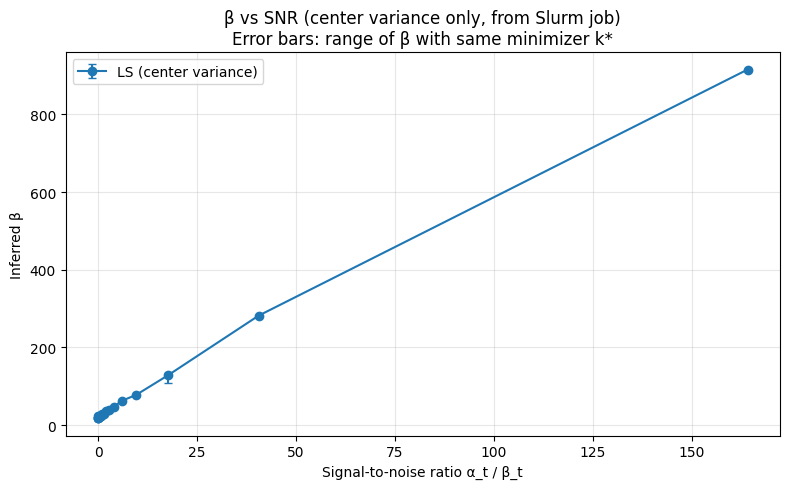

In [10]:
# Figuring out ELS problem in slurm output
slurm_out = ROOT / "results" / "channel_theory" / f"beta_vs_snr_center_variance_{dataset_name}.pt"
if slurm_out.exists():
    data = torch.load(slurm_out, map_location="cpu", weights_only=False)
    snr_arr = np.asarray(data["snr"], dtype=np.float64)
    def to_arr(key, default_nan=None):
        raw = data.get(key)
        if raw is None:
            return np.full(len(snr_arr), np.nan if default_nan is None else default_nan)
        return np.array([x if x is not None else np.nan for x in raw], dtype=np.float64)
    beta_ls_arr = to_arr("beta_ls")
    beta_els_arr = to_arr("beta_els")
    err_lo_ls = to_arr("beta_ls_err_lo", default_nan=0.0)
    err_hi_ls = to_arr("beta_ls_err_hi", default_nan=0.0)
    err_lo_els = to_arr("beta_els_err_lo", default_nan=0.0)
    err_hi_els = to_arr("beta_els_err_hi", default_nan=0.0)
    err_lo_ls = np.where(np.isfinite(err_lo_ls) & (err_lo_ls > 0), err_lo_ls, 0.0)
    err_hi_ls = np.where(np.isfinite(err_hi_ls) & (err_hi_ls > 0), err_hi_ls, 0.0)
    err_lo_els = np.where(np.isfinite(err_lo_els) & (err_lo_els > 0), err_lo_els, 0.0)
    err_hi_els = np.where(np.isfinite(err_hi_els) & (err_hi_els > 0), err_hi_els, 0.0)
    valid_ls = np.isfinite(beta_ls_arr)
    valid_els = np.isfinite(beta_els_arr)
    fig4, ax4 = plt.subplots(1, 1, figsize=(8, 5))
    if np.any(valid_ls):
        ax4.errorbar(
            snr_arr[valid_ls], beta_ls_arr[valid_ls],
            yerr=(err_lo_ls[valid_ls], err_hi_ls[valid_ls]),
            fmt="o-", capsize=3, label="LS (center variance)"
        )
#     if np.any(valid_els):
#         ax4.errorbar(
#             snr_arr[valid_els], beta_els_arr[valid_els],
#             yerr=(err_lo_els[valid_els], err_hi_els[valid_els]),
#             fmt="s-", capsize=3, label="ELS (center variance)"
#         )
    if not (np.any(valid_ls) or np.any(valid_els)):
        print("No finite β values in file. Ensure scale files (e.g. *_median.pt) exist and match --kernelsizes.")
    ax4.set_xlabel("Signal-to-noise ratio α_t / β_t")
    ax4.set_ylabel("Inferred β")
    ax4.set_title("β vs SNR (center variance only, from Slurm job)\nError bars: range of β with same minimizer k*")
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
else:
    print(f"Slurm output not found at {slurm_out}. Run:")
    print("  sbatch scripts/slurm_channel_theory_beta_vs_snr.sh")
    print("or set DATASET=mnist SCALE_FILE_LS=... SCALE_FILE_ELS=... and run the script manually.")

In [11]:
err_lo_ls

array([ 0.        ,  0.        , 20.09218601,  4.08635448,  0.08717969,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ])

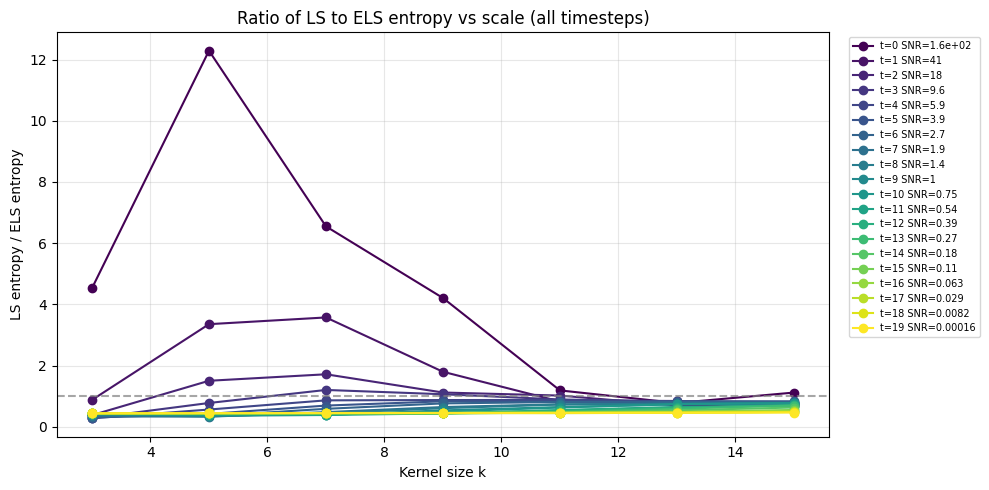

In [12]:
# Ratio of LS to ELS entropy at each scale (k) and timestep (from Slurm job output)
slurm_out = ROOT / "results" / "channel_theory" / f"beta_vs_snr_center_variance_{dataset_name}.pt"
if slurm_out.exists():
    data = torch.load(slurm_out, map_location="cpu", weights_only=False)
    k_vals = np.asarray(data.get("k_vals", []), dtype=np.float64)
    entropy_ls = data.get("entropy_ls")
    entropy_els = data.get("entropy_els")

    if not k_vals.size or entropy_ls is None or entropy_els is None:
        print("Slurm file missing k_vals, entropy_ls, or entropy_els. Re-run the Slurm job.")
    else:
        ent_ls = np.array(entropy_ls, dtype=np.float64)
        ent_els = np.array(entropy_els, dtype=np.float64)
        # ratio[timestep, k_idx] = LS/ELS; avoid div by zero
        with np.errstate(divide="ignore", invalid="ignore"):
            ratio = np.where(ent_els > 0, ent_ls / ent_els, np.nan)
        nsteps = ratio.shape[0]
        snr_list = data.get("snr", [])
        cmap = plt.cm.viridis
        norm = plt.Normalize(vmin=0, vmax=max(1, nsteps - 1))

        fig, ax = plt.subplots(1, 1, figsize=(10, 5))
        for step in range(nsteps):
            c = cmap(norm(step))
            label = f"t={step}" if not snr_list or step >= len(snr_list) else f"t={step} SNR={snr_list[step]:.2g}"
            ax.plot(k_vals, ratio[step], "o-", color=c, label=label)
        ax.set_xlabel("Kernel size k")
        ax.set_ylabel("LS entropy / ELS entropy")
        ax.set_title("Ratio of LS to ELS entropy vs scale (all timesteps)")
        ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)
        ax.grid(True, alpha=0.3)
        ax.axhline(1.0, color="gray", linestyle="--", alpha=0.7)
        plt.tight_layout()
        plt.show()
else:
    print(f"Slurm output not found at {slurm_out}.")

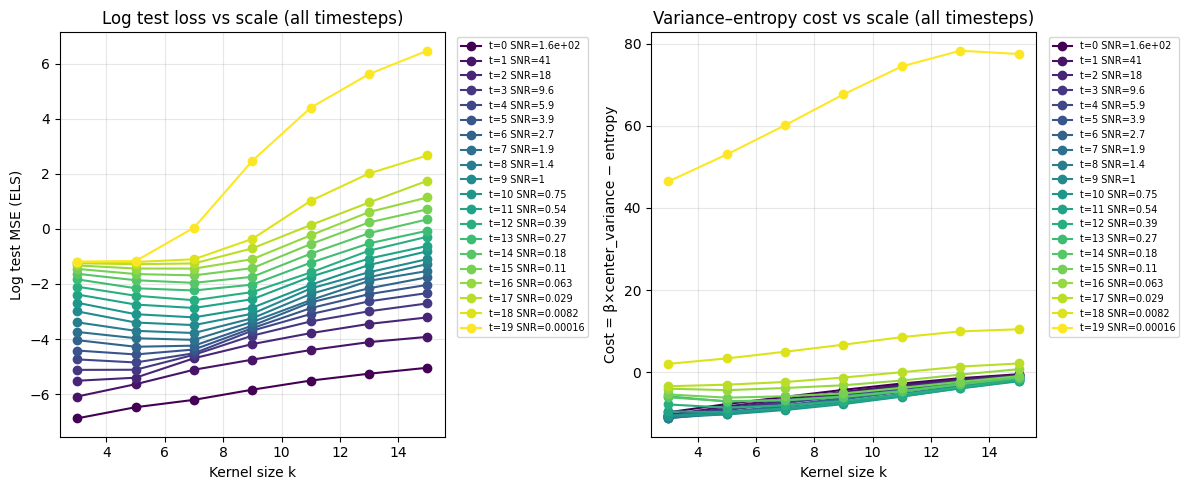

In [13]:
# Compare test loss (MSE) vs variance–entropy cost curve at each timestep
# Load ELS test metrics (test_mse, entropy_els, reg_els) and optionally beta_els for cost
els_metrics_path = ROOT / "results" / "channel_theory" / f"els_test_metrics_{dataset_name}.pt"
beta_snr_path = ROOT / "results" / "channel_theory" / f"beta_vs_snr_center_variance_{dataset_name}.pt"

if els_metrics_path.exists():
    data_els = torch.load(els_metrics_path, map_location="cpu", weights_only=False)
    k_vals = np.asarray(data_els["k_vals"], dtype=np.float64)
    test_mse = np.array(data_els["test_mse"], dtype=np.float64)  # [nsteps, nk]
    entropy_els = np.array(data_els["entropy_els"], dtype=np.float64)
    reg_els = np.array(data_els["reg_els"], dtype=np.float64)
    nsteps = test_mse.shape[0]
    snr_list = data_els.get("snr", list(range(nsteps)))

    # Cost = β×center_variance − entropy; need β per timestep from beta-vs-SNR job
    if beta_snr_path.exists():
        data_beta = torch.load(beta_snr_path, map_location="cpu", weights_only=False)
        beta_list = data_beta.get("beta_els") or []
        beta_els = np.array([b if b is not None else np.nan for b in beta_list], dtype=np.float64)
        if len(beta_els) > nsteps:
            beta_els = beta_els[:nsteps]
        elif len(beta_els) < nsteps:
            beta_els = np.resize(beta_els, nsteps)  # pad or truncate to match
        beta_els = np.broadcast_to(beta_els[:, None], (nsteps, len(k_vals)))
        cost = beta_els * reg_els - entropy_els
        has_cost = True
    else:
        cost = np.full_like(test_mse, np.nan)
        has_cost = False

    cmap = plt.cm.viridis
    norm = plt.Normalize(vmin=0, vmax=max(1, nsteps - 1))

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for step in range(nsteps):
        c = cmap(norm(step))
        label = f"t={step}" if not snr_list or step >= len(snr_list) else f"t={step} SNR={snr_list[step]:.2g}"
        log_mse = np.log(np.maximum(test_mse[step], 1e-12))
        axes[0].plot(k_vals, log_mse, "o-", color=c, label=label)
        if has_cost and np.any(np.isfinite(cost[step])):
            axes[1].plot(k_vals, cost[step], "o-", color=c, label=label)
    axes[0].set_xlabel("Kernel size k")
    axes[0].set_ylabel("Log test MSE (ELS)")
    axes[0].set_title("Log test loss vs scale (all timesteps)")
    axes[0].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)
    axes[0].grid(True, alpha=0.3)
    if has_cost:
        axes[1].set_xlabel("Kernel size k")
        axes[1].set_ylabel("Cost = β×center_variance − entropy")
        axes[1].set_title("Variance–entropy cost vs scale (all timesteps)")
        axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)
        axes[1].grid(True, alpha=0.3)
    else:
        axes[1].text(0.5, 0.5, "Run beta_vs_snr job for cost curve.", ha="center", va="center", transform=axes[1].transAxes)
    plt.tight_layout()
    plt.show()
else:
    print(f"ELS test metrics not found at {els_metrics_path}. Run: sbatch scripts/slurm_channel_theory_els_test_metrics.sh")

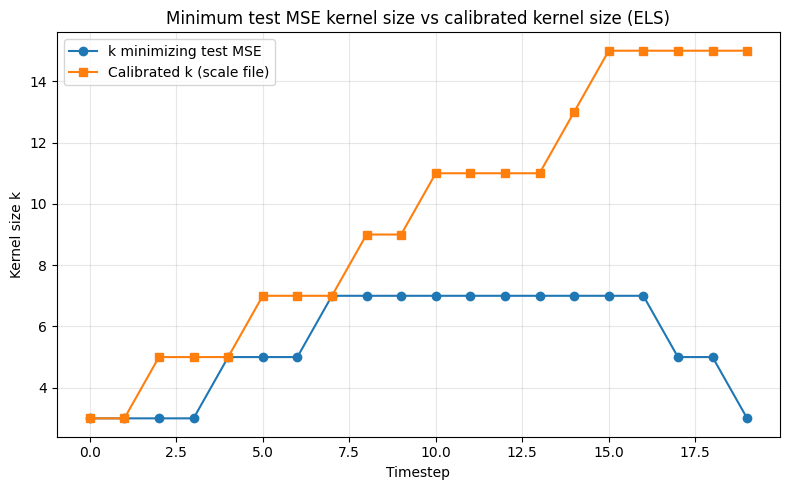

In [18]:
# Minimum test MSE kernel size vs calibrated kernel size (per timestep)
els_metrics_path = ROOT / "results" / "channel_theory" / f"els_test_metrics_{dataset_name}.pt"
if els_metrics_path.exists():
    data_els = torch.load(els_metrics_path, map_location="cpu", weights_only=False)
    k_vals = np.asarray(data_els["k_vals"], dtype=np.float64)
    test_mse = np.array(data_els["test_mse"], dtype=np.float64)
    nsteps = test_mse.shape[0]
    snr_list = data_els.get("snr", list(range(nsteps)))

    # k that minimizes test MSE at each timestep
    k_min_mse = np.array([k_vals[np.nanargmin(test_mse[step])] for step in range(nsteps)])

    # Calibrated k from scale file (same as used for beta inference)
    median_els = load_scale_calibration(scale_file_els, tld)
    if median_els is not None:
        n_cal = median_els.numel()
        k_calibrated = np.full(nsteps, np.nan)
        for s in range(min(nsteps, n_cal)):
            k_calibrated[s] = int(median_els[s].item())
    else:
        k_calibrated = np.full(nsteps, np.nan)

    steps = np.arange(nsteps)
    fig, ax = plt.subplots(1, 1, figsize=(8, 5))
    ax.plot(steps, k_min_mse, "o-", label="k minimizing test MSE", color="C0")
    ax.plot(steps, k_calibrated, "s-", label="Calibrated k (scale file)", color="C1")
    ax.set_xlabel("Timestep")
    ax.set_ylabel("Kernel size k")
    ax.set_title("Minimum test MSE kernel size vs calibrated kernel size (ELS)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print(f"ELS test metrics not found at {els_metrics_path}. Run: sbatch scripts/slurm_channel_theory_els_test_metrics.sh")

In [8]:
# Entropy vs scale (k) for all timesteps (from Slurm job output)
slurm_out = ROOT / "results" / "channel_theory" / f"beta_vs_snr_center_variance_{dataset_name}.pt"
if slurm_out.exists():
    data = torch.load(slurm_out, map_location="cpu", weights_only=False)
    k_vals = np.asarray(data.get("k_vals", []), dtype=np.float64)
    entropy_ls = data.get("entropy_ls")   # list of lists [timestep][k]
    entropy_els = data.get("entropy_els")

    if not k_vals.size or entropy_ls is None or entropy_els is None:
        print("Slurm file missing k_vals, entropy_ls, or entropy_els. Re-run the Slurm job with the updated script.")
    else:
        ent_ls = np.array(entropy_ls, dtype=np.float64)   # [nsteps, nk]
        ent_els = np.array(entropy_els, dtype=np.float64)
        nsteps = ent_ls.shape[0]
        snr_list = data.get("snr", [])
        cmap = plt.cm.viridis
        norm = plt.Normalize(vmin=0, vmax=max(1, nsteps - 1))

        fig, (ax_ls, ax_els) = plt.subplots(1, 2, figsize=(12, 5))
        for step in range(nsteps):
            c = cmap(norm(step))
            label = f"t={step}" if snr_list is None or step >= len(snr_list) else f"t={step} SNR={snr_list[step]:.2g}"
            ax_ls.plot(k_vals, ent_ls[step], "o-", color=c, label=label)
            ax_els.plot(k_vals, ent_els[step], "o-", color=c, label=label)
        ax_ls.set_xlabel("Kernel size k")
        ax_ls.set_ylabel("Average entropy")
        ax_ls.set_title("LS: entropy vs scale (all timesteps)")
        ax_ls.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)
        ax_ls.grid(True, alpha=0.3)
        ax_els.set_xlabel("Kernel size k")
        ax_els.set_ylabel("Average entropy")
        ax_els.set_title("ELS: entropy vs scale (all timesteps)")
        ax_els.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)
        ax_els.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
else:
    print(f"Slurm output not found at {slurm_out}.")

# Variance vs scale (k) for all timesteps (from Slurm job output)
slurm_out = ROOT / "results" / "channel_theory" / f"beta_vs_snr_center_variance_{dataset_name}.pt"
if slurm_out.exists():
    data = torch.load(slurm_out, map_location="cpu", weights_only=False)
    k_vals = np.asarray(data.get("k_vals", []), dtype=np.float64)
    entropy_ls = data.get("reg_ls")   # list of lists [timestep][k]
    entropy_els = data.get("reg_els")

    if not k_vals.size or entropy_ls is None or entropy_els is None:
        print("Slurm file missing k_vals, entropy_ls, or entropy_els. Re-run the Slurm job with the updated script.")
    else:
        ent_ls = np.array(entropy_ls, dtype=np.float64)   # [nsteps, nk]
        ent_els = np.array(entropy_els, dtype=np.float64)
        nsteps = ent_ls.shape[0]
        snr_list = data.get("snr", [])
        cmap = plt.cm.viridis
        norm = plt.Normalize(vmin=0, vmax=max(1, nsteps - 1))

        fig, (ax_ls, ax_els) = plt.subplots(1, 2, figsize=(12, 5))
        for step in range(nsteps):
            c = cmap(norm(step))
            label = f"t={step}" if snr_list is None or step >= len(snr_list) else f"t={step} SNR={snr_list[step]:.2g}"
            ax_ls.plot(k_vals, ent_ls[step], "o-", color=c, label=label)
            ax_els.plot(k_vals, ent_els[step], "o-", color=c, label=label)
        ax_ls.set_xlabel("Kernel size k")
        ax_ls.set_ylabel("Average variance")
        ax_ls.set_title("LS: variance vs scale (all timesteps)")
        ax_ls.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)
        ax_ls.grid(True, alpha=0.3)
        ax_els.set_xlabel("Kernel size k")
        ax_els.set_ylabel("Average variance")
        ax_els.set_title("ELS: variance vs scale (all timesteps)")
        ax_els.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)
        ax_els.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
else:
    print(f"Slurm output not found at {slurm_out}.")

Slurm output not found at /home/users/hshunt/convolutional_diffusion/results/channel_theory/beta_vs_snr_center_variance_MNIST.pt.
Slurm output not found at /home/users/hshunt/convolutional_diffusion/results/channel_theory/beta_vs_snr_center_variance_MNIST.pt.
